In [4]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\udome\Documents\naijacopybench")

def load(p):
    return json.loads((ROOT / p).read_text(encoding="utf-8"))

m1 = load("results/m1_bootstrap.json")["overall"]
m2 = load("results/m2_bootstrap.json")["overall"]
m4 = load("results/m4_scored.json")["by_arm"]

ARMS  = ["A1", "A2", "A3", "A5"]
NAMES = {"A1":"Qwen-3B", "A2":"Qwen-3B tuned", "A3":"gpt-4o-mini", "A5":"gpt-4o-mini+RAG"}
COL   = {"A1":"#95a5a6", "A2":"#8e44ad", "A3":"#2980b9", "A5":"#16a085"}

print("m1:", m1)
print("m2:", m2)

m1: {'A1': {'rate': 34.58904109589041, 'lo': 26.923076923076923, 'hi': 42.32081911262799}, 'A2': {'rate': 37.083333333333336, 'lo': 29.761904761904763, 'hi': 44.72573839662447}, 'A3': {'rate': 25.91362126245847, 'lo': 19.801980198019802, 'hi': 32.19178082191781}, 'A5': {'rate': 12.467532467532468, 'lo': 8.311688311688311, 'hi': 17.04260651629073}}
m2: {'A1': {'acc': 4.827586206896552, 'lo': 2.0689655172413794, 'hi': 8.275862068965518}, 'A2': {'acc': 28.275862068965516, 'lo': 21.379310344827587, 'hi': 35.86206896551724}, 'A3': {'acc': 3.4482758620689653, 'lo': 0.6896551724137931, 'hi': 6.896551724137931}, 'A5': {'acc': 49.6551724137931, 'lo': 41.37931034482759, 'hi': 57.93103448275862}}


In [3]:
from pathlib import Path
print("cwd:", Path.cwd())

cwd: C:\Users\udome\Documents\naijacopybench\results


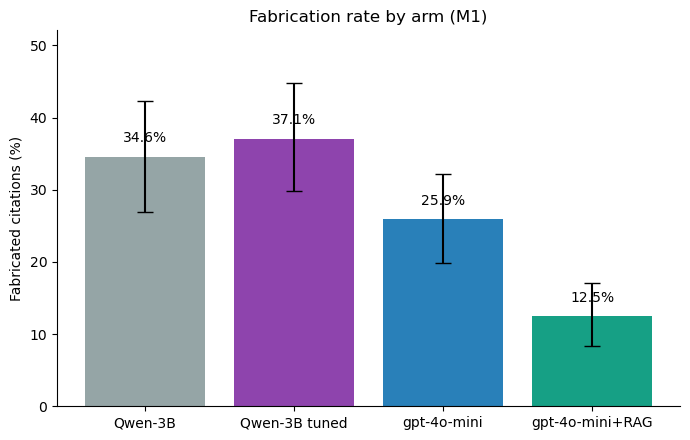

In [5]:
arms = [a for a in ARMS if a in m1]
vals = [m1[a]["rate"] for a in arms]
err  = [[m1[a]["rate"]-m1[a]["lo"] for a in arms],
        [m1[a]["hi"]-m1[a]["rate"] for a in arms]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([NAMES[a] for a in arms], vals, yerr=err, capsize=6,
       color=[COL[a] for a in arms])
for a, v in zip(arms, vals):
    ax.text(NAMES[a], v+2, f"{v:.1f}%", ha="center")
ax.set_ylabel("Fabricated citations (%)")
ax.set_title("Fabrication rate by arm (M1)")
ax.set_ylim(0, max(vals)+15)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT/"figures/fig_m1.png", dpi=300, bbox_inches="tight")
plt.show()